In [2]:
library("tidyverse")
library(glmnet) 
library(survival)
library(dplyr)
library(survminer)
library(DESeq2)

In [3]:
exp_data <- read.csv("./../data/ICGC/OV-AU_normalized_read_count_gene_by_sample.csv")
row.names(exp_data) <- exp_data$gene_id
exp_data$gene_id <- NULL
print(dim(exp_data))

[1] 56206   111


In [4]:
metadata <- read.csv("./../data/ICGC/OV-AU_specimen_histology_metadata.tsv", sep = "\t")
print(dim(metadata))
print(table(metadata$specimen_type))
metadata <- filter(metadata, specimen_type == "Primary tumour - solid tissue" )
print(dim(metadata))
rownames(metadata) <- metadata$icgc_donor_id
print(dim(metadata))
print(table(metadata$specimen_donor_treatment_type))

[1] 209  29

Metastatic tumour - metastasis to distant location 
                                                 3 
                            Normal - blood derived 
                                                78 
                         Normal - EBV immortalized 
                                                15 
                            Primary tumour - other 
                                                 4 
                     Primary tumour - solid tissue 
                                                81 
                          Recurrent tumour - other 
                                                25 
                   Recurrent tumour - solid tissue 
                                                 3 
[1] 81 29
[1] 81 29

 no treatment other therapy       surgery 
           70             6             5 


In [5]:
metadata2 <- read.csv("./../data/ICGC/OV-AU_sample_metadata_with_header.tsv", sep = "\t")
print(dim(metadata2))
metadata2 <- filter(metadata2, metadata2$icgc_sample_id  %in% colnames(exp_data) )
print(dim(metadata2))
metadata2 <- filter(metadata2, metadata2$icgc_specimen_id  %in% metadata$icgc_specimen_id )
print(dim(metadata2))
rownames(metadata2) <- metadata2$icgc_donor_id
print(dim(metadata2))

[1] 325  11
[1] 111  11
[1] 81 11
[1] 81 11


In [6]:
exp_data <- exp_data[, metadata2$icgc_sample_id]
print(dim(exp_data))
print(table(colnames(exp_data) == metadata2$icgc_sample_id))
colnames(exp_data) <- rownames(metadata2)
print(dim(exp_data))

[1] 56206    81

TRUE 
  81 
[1] 56206    81


In [7]:
clinical_data <- read.csv("./../data/ICGC/OV-AU_donor_clinical_metadata.tsv", sep = "\t")
rownames(clinical_data) <- clinical_data$icgc_donor_id
print(dim(clinical_data))
clinical_data <- clinical_data[colnames(exp_data), ]
print(dim(clinical_data))
print(table(colnames(exp_data) == rownames(clinical_data)))
print(table(clinical_data$donor_vital_status))
clinical_data$os_event <- ifelse(
    clinical_data$donor_vital_status == "deceased",
    1,
    ifelse(
        clinical_data$donor_vital_status == "alive",
        0,
        NA
    )
)

[1] 93 21
[1] 81 21

TRUE 
  81 

   alive deceased 
      15       66 


In [8]:
geneAnnotation <- read.csv("./../data/ICGC/Human.GRCh38.p13.annot.tsv", sep = "\t")
print(dim(geneAnnotation))

[1] 39376    18


## Risk MOdel

In [9]:
coef_model <- c(
  FCGBP = 0.149229345997741,
  ANGPTL4 = 0.133669816923914,
  CCDC28A = 0.125852702572412,
  RXFP1 = -0.20884516234645, 
  PRKAR1B = 0.216102568992537, 
  VTA1 = 0.176810198243516, 
  PRRG1 = 0.14334225824553, 
  CALB1 = 0.209094298041635,
  DKK1 = 0.180006113308806,
  CXCL13 = -0.242696158184245,
  RALGAPB = 0.193062112568582

)

cutoff <- -0.01261388

genes_model <- names(coef_model)
genes_model %in% geneAnnotation$Symbol

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

In [10]:
subset_geneAnnotation <- filter(geneAnnotation, geneAnnotation$Symbol %in% genes_model)
rownames(subset_geneAnnotation) <- subset_geneAnnotation$EnsemblGeneID
print(dim(subset_geneAnnotation))

[1] 11 18


In [11]:
geneSymbol <- c()
for (i in subset_geneAnnotation$EnsemblGeneID){
    if (i %in% rownames(exp_data)){
        print("available")
    }else{
        print(i)
    }
}

[1] "available"
[1] "available"
[1] "available"
[1] "available"
[1] "available"
[1] "available"
[1] "available"
[1] "available"
[1] "ENSG00000275395"
[1] "available"
[1] "available"


In [12]:
"ENSG00000090920" %in% rownames(exp_data)

[1] TRUE

In [13]:
subset_exp <- exp_data[c(intersect(subset_geneAnnotation$EnsemblGeneID, rownames(exp_data)), "ENSG00000090920" ) , ]
print(dim(subset_exp))
rownames(subset_exp) <- c(subset_geneAnnotation[intersect(subset_geneAnnotation$EnsemblGeneID, rownames(exp_data)),]$Symbol, "FCGBP")
subset_exp <- t(subset_exp)
print(dim(subset_exp))
head(subset_exp, 10)

[1] 11 81
[1] 81 11


,CXCL13,RXFP1,CCDC28A,VTA1,PRKAR1B,CALB1,DKK1,ANGPTL4,RALGAPB,PRRG1,FCGBP
DO46325,12.65,0.06,7.71,21.31,7.98,1.01,0.19,19.68,16.62,3.19,15.52
DO46326,5.00,0.04,22.51,23.52,8.03,2.23,2.00,1.66,15.00,2.78,13.82
DO46327,1.94,0.37,9.88,29.93,7.31,545.48,2.02,30.59,13.04,10.90,2.55
DO46328,0.65,0.14,14.24,34.60,12.52,3.33,0.02,2.97,12.38,2.79,3.70
DO46329,2.19,0.20,6.97,17.13,10.89,5.94,0.09,6.86,7.76,0.24,2.76
DO46330,0.52,0.08,10.73,36.62,33.15,0.09,0.01,2.60,16.73,4.72,20.83
DO46331,0.11,0.02,10.58,9.11,24.71,0.58,0.03,6.98,4.85,0.85,4.19
DO46332,3.95,0.09,11.84,20.04,9.66,5.90,0.49,10.26,13.08,4.02,0.76
DO46333,0.35,0.00,11.95,4.33,15.12,0.36,1.02,5.78,2.97,0.14,5.60
DO46334,7.34,0.50,7.99,32.82,12.35,1.27,0.31,3.81,13.18,3.16,1.49


In [14]:
validation_scaled <- scale(subset_exp)

In [15]:
validation_risk_score <- as.numeric(
  as.matrix(validation_scaled[, names(coef_model), drop = FALSE]) %*%
    coef_model
)

names(validation_risk_score) <- rownames(validation_scaled)

In [16]:
validation_data <- data.frame(
  icgc_donor_id = rownames(subset_exp),
  risk_score = validation_risk_score,
  #risk_group = validation_risk_group,
  row.names = rownames(subset_exp)
)
head(validation_data)

validation_data <- merge(
  validation_data,
  clinical_data[, c(
    "icgc_donor_id",
    "donor_survival_time",
    "donor_vital_status",
      "os_event"
  )],
  by = "icgc_donor_id"
)
head(validation_data)

,icgc_donor_id,risk_score
,<chr>,<dbl>
DO46325,DO46325,0.06530654
DO46326,DO46326,1.05726906
DO46327,DO46327,3.17335077
DO46328,DO46328,0.28419823
DO46329,DO46329,-0.62510438
DO46330,DO46330,1.42178925


,icgc_donor_id,risk_score,donor_survival_time,donor_vital_status,os_event
,<chr>,<dbl>,<int>,<chr>,<dbl>
1,DO46325,0.06530654,477,deceased,1
2,DO46326,1.05726906,701,deceased,1
3,DO46327,3.17335077,184,deceased,1
4,DO46328,0.28419823,972,deceased,1
5,DO46329,-0.62510438,1699,deceased,1
6,DO46330,1.42178925,684,deceased,1


In [17]:
validation_data$risk_group <- ifelse(
  validation_risk_score > cutoff,
  "High",
  "Low"
)

validation_data$risk_group <- factor(
  validation_data$risk_group,
  levels = c("Low", "High")
)
table(validation_data$risk_group)


 Low High 
  43   38 

In [18]:
summary(validation_data["risk_score"])

   risk_score      
 Min.   :-1.74812  
 1st Qu.:-0.42758  
 Median :-0.06037  
 Mean   : 0.00000  
 3rd Qu.: 0.33143  
 Max.   : 3.17335  

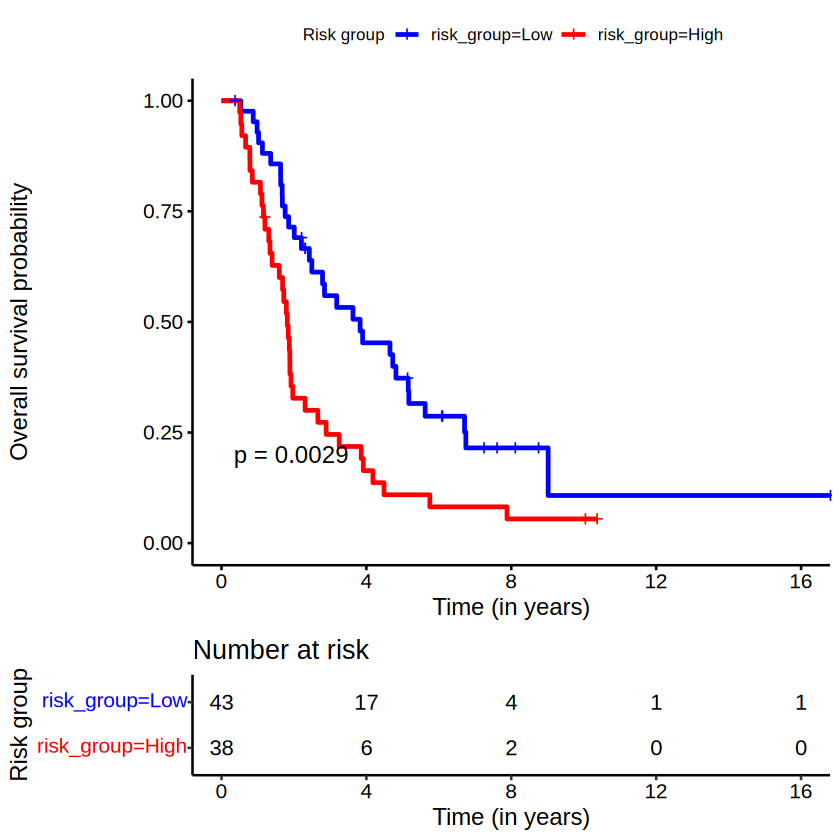

In [19]:
km_fit <- survfit(
  Surv(donor_survival_time/365.25, os_event) ~ risk_group,
  data = validation_data
)

ggsurvplot(
  km_fit,
  data = validation_data,
  risk.table = TRUE,
  pval = TRUE,
  #conf.int = TRUE,
  xlab = "Time (in years)",
  ylab = "Overall survival probability",
  legend.title = "Risk group",
    palette = c("blue", "red")
)

In [20]:
# png(filename = "./results/ICGC_riskStratification_survival_plot.png", width = 1800, height = 1500, res = 300)
# ggsurvplot(
#   km_fit,
#   data = validation_data,
#   risk.table = TRUE,
#   pval = TRUE,
#   #conf.int = TRUE,
#   xlab = "Time (in years)",
#   ylab = "Overall survival probability",
#   legend.title = "Risk group",
#     palette = c("blue", "red")
# )
# dev.off()

In [21]:
survdiff(
  Surv(donor_survival_time, os_event) ~ risk_group,
  data = validation_data
)

Call:
survdiff(formula = Surv(donor_survival_time, os_event) ~ risk_group, 
    data = validation_data)

                 N Observed Expected (O-E)^2/E (O-E)^2/V
risk_group=Low  43       31     42.4      3.08      8.87
risk_group=High 38       35     23.6      5.56      8.87

 Chisq= 8.9  on 1 degrees of freedom, p= 0.003 

In [22]:
cox_cont <- coxph(
    Surv(donor_survival_time, os_event) ~ risk_score,
    data = validation_data
)

summary(cox_cont)

Call:
coxph(formula = Surv(donor_survival_time, os_event) ~ risk_score, 
    data = validation_data)

  n= 81, number of events= 66 

             coef exp(coef) se(coef)     z Pr(>|z|)   
risk_score 0.5059    1.6585   0.1845 2.742  0.00611 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

           exp(coef) exp(-coef) lower .95 upper .95
risk_score     1.659     0.6029     1.155     2.381

Concordance= 0.596  (se = 0.038 )
Likelihood ratio test= 7.45  on 1 df,   p=0.006
Wald test            = 7.52  on 1 df,   p=0.006
Score (logrank) test = 7.56  on 1 df,   p=0.006
